In [1]:
import os
import re
import pandas as pd
from collections import defaultdict

BASE_DIR = "results_docking"

# regex to capture vina affinity lines
affinity_pattern = re.compile(r"^\s*1\s+(-?\d+\.\d+)\s+")

data = []

for protein in os.listdir(BASE_DIR):
    protein_path = os.path.join(BASE_DIR, protein)
    if not os.path.isdir(protein_path):
        continue

    for ligand in os.listdir(protein_path):
        ligand_path = os.path.join(protein_path, ligand)
        if not os.path.isdir(ligand_path):
            continue

        for file in os.listdir(ligand_path):
            if not file.endswith(".log"):
                continue

            log_path = os.path.join(ligand_path, file)

            # extract replicate number if exists
            rep_match = re.search(r"rep(\d+)", file)
            rep = int(rep_match.group(1)) if rep_match else None

            affinity = None

            with open(log_path, "r") as f:
                for line in f:
                    m = affinity_pattern.match(line)
                    if m:
                        affinity = float(m.group(1))
                        break

            if affinity is not None:
                data.append({
                    "protein": protein,
                    "ligand": ligand,
                    "replicate": rep,
                    "affinity": affinity
                })

df = pd.DataFrame(data)


In [2]:
df["ligand"].unique()

array(['10176710', '10394', '104775', '10559720', '107', '175', '348154',
       '439435', '49831816', '6262', '689043', '9877619', 'm1', 'm2',
       'm3', 'm4', 'rf', 'rolR', 'rolS'], dtype=object)

In [3]:
# ---- per ligand mean/std ----
summary = (
    df.groupby(["protein", "ligand"])
      .agg(mean_affinity=("affinity", "mean"),
           std_affinity=("affinity", "std"),
           n=("affinity", "count"))
      .reset_index()
)

In [4]:
df.to_csv("vina_replicates.csv", index=False)
summary.to_csv("vina_summary.csv", index=False)

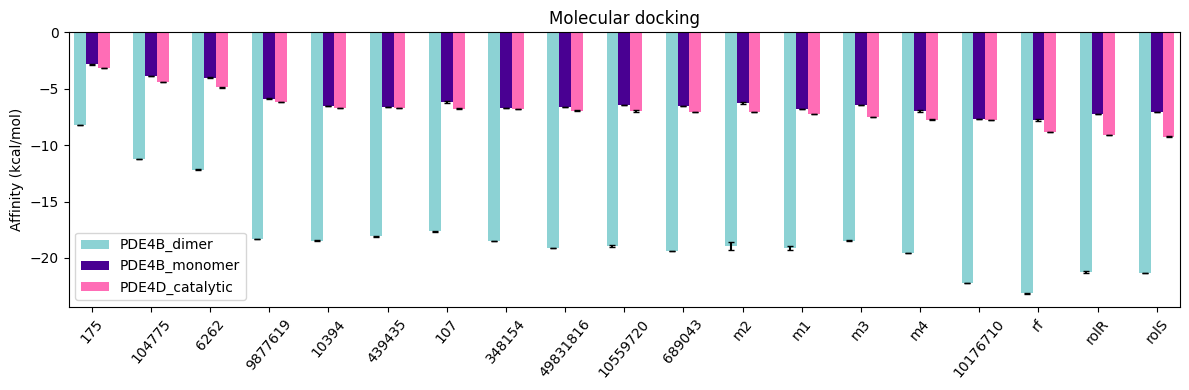

In [59]:
import matplotlib.pyplot as plt
import numpy as np

colors = ["8cd2d4", "490092", "ff6db6"]

to_remove = ["PDE4B_catalytic"]
proteins = df[~df["protein"].isin(to_remove)]["protein"].unique()

# Order ligands based on PDE4D_catalytic affinity: lowest → highest
ligands = (
    summary[summary["protein"] == "PDE4D_catalytic"]
    .sort_values("mean_affinity", ascending=False)["ligand"]
    .tolist()
)

x = np.arange(len(ligands))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 4))

for i, protein in enumerate(proteins):
    sub = (
        summary[summary["protein"] == protein]
        .set_index("ligand")
        .reindex(ligands)
    )

    ax.bar(
        x + i * width,
        sub["mean_affinity"],
        width,
        yerr=sub["std_affinity"],
        capsize=2,
        label=protein,
        color=f"#{colors[i % len(colors)]}"
    )
    
ax.margins(x=0.005)
ax.set_xticks(x + width)
ax.set_xticklabels(ligands, rotation=50)
ax.set_ylabel("Affinity (kcal/mol)")
ax.set_title("Molecular docking")
ax.legend()

plt.tight_layout()
plt.show()

In [58]:
summary[summary["ligand"] == "m4"]

,protein,ligand,mean_affinity,std_affinity,n
15,PDE4B_catalytic,m4,-6.833333,0.057735,3
34,PDE4B_dimer,m4,-19.600000,0.000000,3
53,PDE4B_monomer,m4,-6.966667,0.057735,3
72,PDE4D_catalytic,m4,-7.733333,0.057735,3


In [ ]:
summary[summary["ligand"] == "m4"]

9877619, 175, 6262, 104775, 107 nao
439435 no monomero sim, dimer nao
10395 um pouco maior na B


/tmp/ipykernel_128363/3348774952.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=45)
/tmp/ipykernel_128363/3348774952.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=45)
/tmp/ipykernel_128363/3348774952.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=45)
/tmp/ipykernel_128363/3348774952.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=45)
/tmp/ipykernel_128363/3348774952.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after s

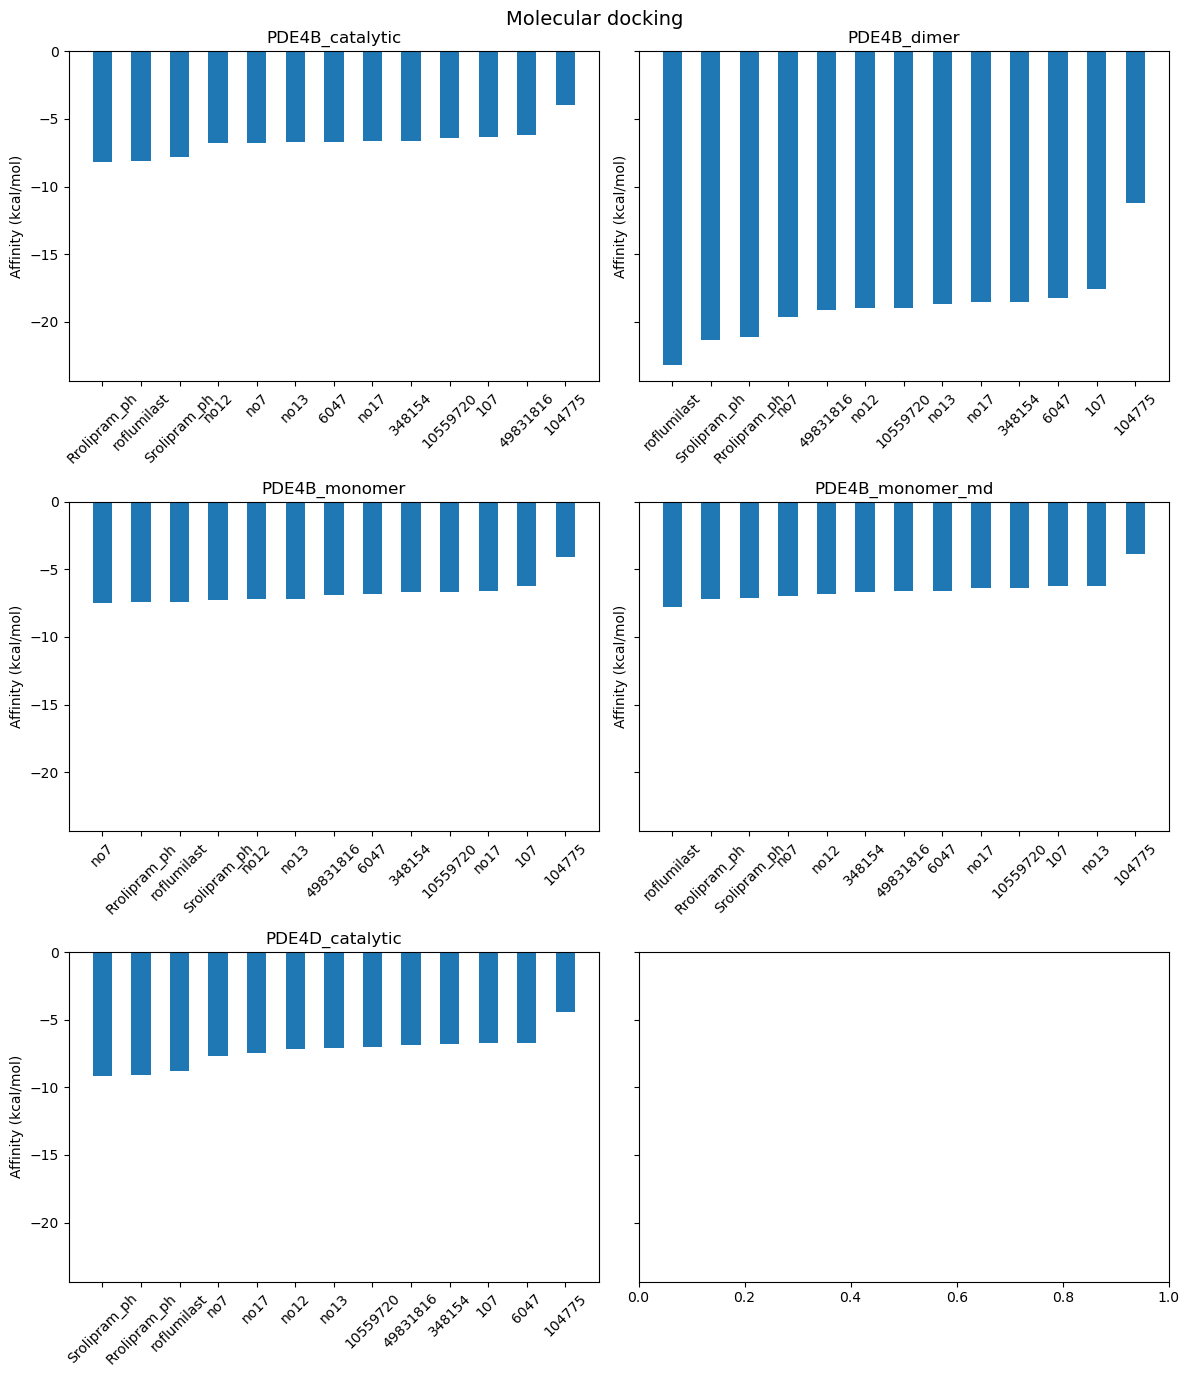

In [38]:
import matplotlib.pyplot as plt

df_rep1 = df[df["replicate"] == 1]

fig, axes = plt.subplots(3, 2, figsize=(10, 14), sharey=True)
axes = axes.ravel()

proteins = df_rep1["protein"].unique()
#proteins = df[df["protein"] != "PDE4B_monomer_md"]["protein"].unique()

for ax, protein in zip(axes, proteins):
    sub = df_rep1[df_rep1["protein"] == protein].sort_values("affinity")
    ax.bar(sub["ligand"], sub["affinity"], width=0.5)
    ax.set_title(protein)
    ax.set_xticklabels(sub["ligand"], rotation=45)
    ax.set_ylabel("Affinity (kcal/mol)")

fig.suptitle("Molecular docking", fontsize=14)
plt.tight_layout()
plt.show()